# Phase 8 — Model 2: Mobile Money Adoption

This notebook independently trains and evaluates `account_mob` using Model 2's own feature matrix and group-aware splits. The validated financial-inclusion pipeline is protected from modification. SHAP and application work are outside this phase.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MPLBACKEND', 'Agg')
project_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').is_file())
sys.path.insert(0, str(project_root / 'src'))

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from finaccess_eswatini.phase8_model2 import run

summary = run()
report_dir = project_root / 'reports' / 'phase_8'
print('Selected mobile-money model:', summary['selection']['selected_model_label'])
print('Protected holdout rows:', summary['split']['test_rows'])
print('Profile overlap across holdout:', summary['split']['profile_overlap_count'])
print('Model 1 pipeline unchanged:', summary['model1_safeguard']['unchanged'])

Selected mobile-money model: Logistic Regression
Protected holdout rows: 210
Profile overlap across holdout: 0
Model 1 pipeline unchanged: True


## Independent training-fold comparison

The candidates use Model 2 preprocessing and Model 2 group-aware folds. No Model 1 tuning result or protected holdout metric determines this selection.

,model,parameter_combinations,cv_mean_roc_auc,cv_std_roc_auc,cv_mean_accuracy,cv_mean_precision,cv_mean_recall,cv_mean_f1,cv_mean_brier,train_cv_roc_auc_gap,within_one_se_of_best_auc,selected
3,Random Forest,12,0.7158,0.0471,0.6789,0.6774,0.8569,0.7562,0.2080,0.2048,True,False
4,Gradient Boosting,16,0.7116,0.0321,0.6635,0.6767,0.8078,0.7360,0.2115,0.0947,True,False
1,Logistic Regression,6,0.7097,0.0425,0.6575,0.7129,0.6891,0.7001,0.2141,0.0497,True,True
2,Decision Tree,18,0.6868,0.0262,0.6433,0.6585,0.8140,0.7233,0.2210,0.0390,False,False
0,Dummy majority baseline,1,0.5000,0.0000,0.5815,0.5815,1.0000,0.7353,0.2434,0.0000,False,False


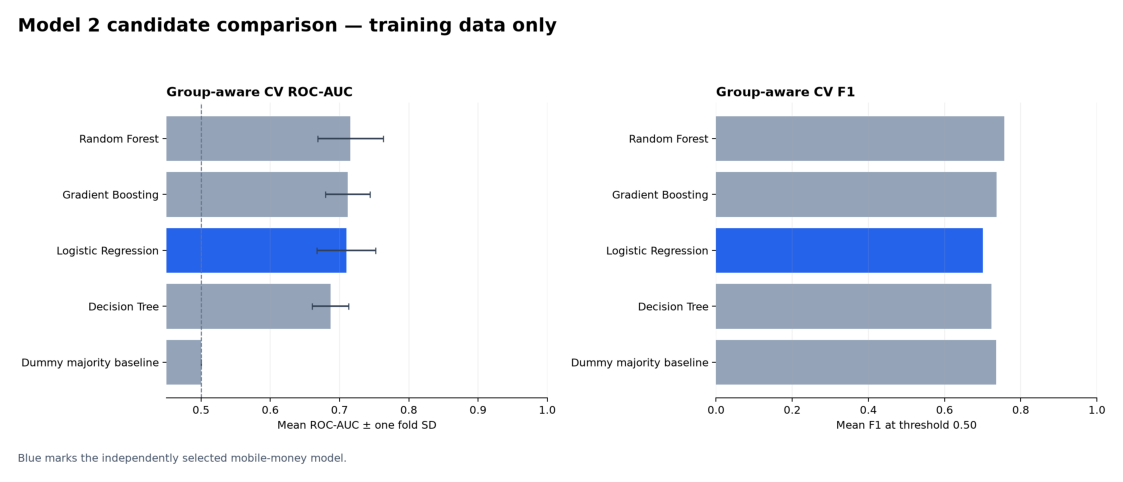

In [2]:
comparison = pd.read_csv(report_dir / 'model_comparison.csv')
comparison_view = comparison[[
    'model', 'parameter_combinations', 'cv_mean_roc_auc', 'cv_std_roc_auc',
    'cv_mean_accuracy', 'cv_mean_precision', 'cv_mean_recall', 'cv_mean_f1',
    'cv_mean_brier', 'train_cv_roc_auc_gap', 'within_one_se_of_best_auc', 'selected'
]].copy()
numeric = comparison_view.select_dtypes('number').columns
comparison_view[numeric] = comparison_view[numeric].round(4)
display(comparison_view.sort_values('cv_mean_roc_auc', ascending=False))

image = mpimg.imread(report_dir / 'figures' / '01_model_comparison.png')
plt.figure(figsize=(15, 6))
plt.imshow(image)
plt.axis('off')
plt.show()

## Protected mobile-money holdout

Only the independently selected Model 2 pipeline is evaluated. Bootstrap intervals quantify uncertainty, and the provisional 0.50 threshold is not optimized on this holdout.

,metric,value,lower_95,upper_95
0,accuracy,0.6762,0.6095,0.7381
1,balanced_accuracy,0.6675,NaN,NaN
2,precision,0.7213,0.6692,0.7787
3,recall,0.7213,0.6393,0.7951
4,f1,0.7213,0.6609,0.7747
5,roc_auc,0.7256,0.6567,0.7905
6,brier_score,0.2053,0.1862,0.2255
7,log_loss,0.5964,NaN,NaN


predicted,0,1
actual,,
0,54,34
1,34,88


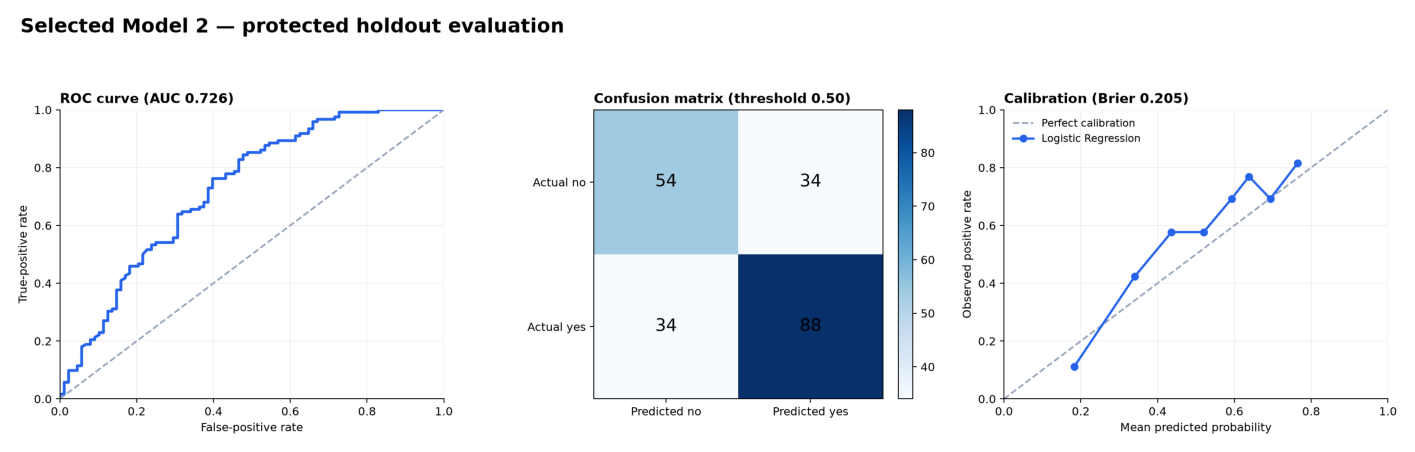

In [3]:
metrics = pd.read_csv(report_dir / 'holdout_metrics.csv')
intervals = pd.read_csv(report_dir / 'bootstrap_intervals.csv')
results = metrics.merge(intervals[['metric', 'lower_95', 'upper_95']], on='metric', how='left')
display(results.round(4))

confusion = pd.read_csv(report_dir / 'confusion_matrix.csv')
display(confusion.pivot(index='actual', columns='predicted', values='count'))

image = mpimg.imread(report_dir / 'figures' / '02_holdout_evaluation.png')
plt.figure(figsize=(18, 6))
plt.imshow(image)
plt.axis('off')
plt.show()

## Generalisation and scope guardrails

These results support predictive evaluation only. Global and individual explanations for both models remain reserved for Phase 9.

In [4]:
print('Train–CV AUC gap:', round(summary['diagnostics']['train_cv_auc_gap'], 4))
print('Holdout minus CV AUC:', round(summary['diagnostics']['holdout_minus_cv_auc'], 4))
print('Expected calibration error:', round(summary['diagnostics']['expected_calibration_error'], 4))
print('Unseen holdout categories:', summary['diagnostics']['unseen_holdout_category_count'])
print('\nImportant limitations:')
for limitation in summary['limitations']:
    print(f'• {limitation}')

Train–CV AUC gap: 0.0497
Holdout minus CV AUC: 0.0159
Expected calibration error: 0.0791
Unseen holdout categories: 1

Important limitations:
• small protected holdout produces material metric uncertainty
• 77 respondents belong to identical predictor profiles with conflicting outcomes
• recent internet and data-purchase features overlap the target observation period
• observational predictors do not support causal claims
• 0.50 threshold remains provisional
• survey weights were not used as predictors or loss weights
